# Axon-logger JSON -> per-signal DataFrames

Converts a Hermle "axon logger" `*.raw.json` export (e.g. `data/Hermle/20260629/axon_logger_ptw_001.raw.json`)
into one DataFrame per signal channel.

This file uses a different schema than the `*.processed.json` files handled by
`json2csv.ipynb`: every record here carries exactly **one** signal channel's
`data` array, tagged by `sensortype`/`sensoridx` (`acceleration`, `distance`,
`force` for `sensoridx` 0-2, plus a single `machine` channel). Crucially, the
array length is **not** the same across channels:

- `acceleration_*` and `force_*`: 20000 samples per block
- `distance_*`: 10000 samples per block
- `machine_0`: 250 samples per block, but each "sample" is itself a nested
  machine-state snapshot (10 axes x 11 fields, plus ~35 scalar/boolean
  fields), not a number.

Because of this, the result is a `dict[str, pd.DataFrame]` (one entry per
signal) rather than one combined table:

- the 9 numeric channels each become a **wide** DataFrame: one row per
  block, one column per sample index.
- `machine_0` becomes a DataFrame with one row per individual sample, since
  its samples aren't scalars and can't be laid out as sample columns.

In [172]:
import json
from collections import defaultdict
from datetime import datetime
from pathlib import Path
import re

import numpy as np
import pandas as pd
from ipyfilechooser import FileChooser
from IPython.display import display

## 1 - Pick the source JSON file

Starts in `data/Hermle/20260629` with `axon_logger_ptw_001.raw.json` pre-selected
(`select_default=True`) so the rest of the notebook can run end-to-end without
clicking through the widget; pick a different file in the widget to convert
another archive.

In [173]:
fc = FileChooser(
    "../data/Hermle/20260630",
    filename="axon_logger_ptw_Lev006.raw.json",
    select_default=True,
)
fc.filter_pattern = ["*.json"]
display(fc)

FileChooser(path='C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\Hermle\20260630', filename='axon_l…

## 2 - Load and inspect

Loads the whole file with `json.load` (plain `json.load` handles ~200 MB in a
couple of seconds, no streaming needed) and looks at the schema of one record.

In [174]:
json_path = Path(fc.selected)

with open(json_path) as f:
    records = json.load(f)

print(f"{json_path.name}: {len(records)} records ({json_path.stat().st_size / 1e6:.1f} MB)")

record = records[0]
for key, value in record.items():
    if isinstance(value, list):
        inner = f", inner_type={type(value[0]).__name__}" if value else ""
        print(f"  {key:14s} list, len={len(value)}{inner}")
    else:
        print(f"  {key:14s} {type(value).__name__} = {value}")

axon_logger_ptw_Lev006.raw.json: 6509 records (1855.7 MB)
  _id            dict = {'$oid': '6a42881df05d89a4522faaee'}
  data           list, len=20000, inner_type=int
  device         str = C1E0F730-A3B4-3001-363B-32753AA0371F
  process        int = 1
  sensoridx      int = 2
  sensortype     str = acceleration
  spindleidx     int = 0
  time           dict = {'$date': '2026-06-29T14:54:37.579Z'}
  workpiecedata  list, len=1, inner_type=dict


## 3 - Per-record (block) metadata

Every record/block carries the same identity fields regardless of signal
type: a Mongo `_id`, a `time`, the `process` flag, the `sensortype`/`sensoridx`
pair that determines which signal it belongs to, and one `workpiecedata`
entry (`materialnr`, `batchnr`, `serialnr`).

`spindleidx` is constant `0` for every record in this archive; `extract_block_meta`
asserts that rather than silently grouping different spindles together if a
future export changes that.

In [175]:
def extract_block_meta(record: dict) -> dict:
    """Pull the per-record identity/scalar fields shared by every sensor type."""
    if record["spindleidx"] != 0:
        raise ValueError(
            f"record {record['_id']['$oid']}: unexpected spindleidx={record['spindleidx']}"
        )

    wp = record["workpiecedata"][0]
    return {
        "id": record["_id"]["$oid"],
        "time": pd.Timestamp(record["time"]["$date"]),
        "process": record["process"],
        "sensortype": record["sensortype"],
        "sensoridx": record["sensoridx"],
        "materialnr": int(wp["materialnr"]["$numberLong"]),
        "batchnr": int(wp["batchnr"]["$numberLong"]),
        "serialnr": "-".join(str(s["$numberLong"]) for s in wp["serialnr"]),
    }


extract_block_meta(record)

{'id': '6a42881df05d89a4522faaee',
 'time': Timestamp('2026-06-29 14:54:37.579000+0000', tz='UTC'),
 'process': 1,
 'sensortype': 'acceleration',
 'sensoridx': 2,
 'materialnr': 10,
 'batchnr': 1,
 'serialnr': '101-26-26-1-1'}

## 4 - Group records by signal

A "signal" is one `sensortype`/`sensoridx` combination. Each group's blocks
are sorted by `time` and keep their raw `data` payload alongside the parsed
metadata, ready to be flattened.

In [176]:
groups = defaultdict(list)
for rec in records:
    meta = extract_block_meta(rec)
    signal_name = f"{meta['sensortype']}_{meta['sensoridx']}"
    groups[signal_name].append((meta, rec["data"]))

for items in groups.values():
    items.sort(key=lambda item: item[0]["time"])

print(f"{len(groups)} signals:")
for signal_name in sorted(groups):
    print(f"  {signal_name:14s} {len(groups[signal_name]):3d} blocks")

10 signals:
  acceleration_0 630 blocks
  acceleration_1 647 blocks
  acceleration_2 656 blocks
  distance_0     616 blocks
  distance_1     623 blocks
  distance_2     642 blocks
  force_0        664 blocks
  force_1        674 blocks
  force_2        686 blocks
  machine_0      671 blocks


## 5 - Build one waveform signal (test)

`build_waveform_df` lays out a numeric channel wide: one row per block, one
column per sample index (`s0000`, `s0001`, ...). It raises if a block's
`data` length doesn't match the rest of the group, instead of silently
misaligning columns.

Tested here on `acceleration_0` before running it over every numeric
channel.

In [177]:
def build_waveform_df(items: list[tuple[dict, list]]) -> pd.DataFrame:
    """One row per block: block metadata + one column per sample index."""
    sample_len = len(items[0][1])
    width = len(str(sample_len - 1))
    sample_cols = [f"s{i:0{width}d}" for i in range(sample_len)]

    meta_rows = []
    data_matrix = np.empty((len(items), sample_len))
    for block_idx, (meta, data) in enumerate(items):
        if len(data) != sample_len:
            raise ValueError(
                f"block {block_idx} ({meta['id']}): data length {len(data)} != {sample_len}"
            )
        data_matrix[block_idx] = data
        meta_rows.append({**meta, "block_idx": block_idx})

    meta_df = pd.DataFrame(meta_rows)
    sample_df = pd.DataFrame(data_matrix, columns=sample_cols)
    return pd.concat([meta_df, sample_df], axis=1)


test_df = build_waveform_df(groups["acceleration_0"])
print(f"shape: {test_df.shape}")
test_df.iloc[:3, :12]

shape: (630, 20009)


,id,time,process,sensortype,sensoridx,materialnr,batchnr,serialnr,block_idx,s00000,s00001,s00002
0,6a4289b0f05d89a4522fbae4,2026-06-29 15:01:14.579000+00:00,0,acceleration,0,10,1,101-26-26-1-1,0,-10.0,-7.0,-10.0
1,6a437a35a8e7fab522e01204,2026-06-30 08:07:27.049000+00:00,0,acceleration,0,10,1,101-26-26-2-1,1,-21.0,-17.0,-20.0
2,6a437a35a8e7fab522e01202,2026-06-30 08:07:30.049000+00:00,0,acceleration,0,10,1,101-26-26-2-1,2,-25.0,-20.0,-21.0


## 6 - Flatten one machine sample (test)

Each `machine_0` sample is a nested machine-state snapshot rather than a
number: 10 `axes` (each with 11 fields), a handful of fixed-length lists
(`io`, `toolclamping`, `toollife`), its own `materialnr`/`batchnr`/`serialnr`
(renamed `mc_*` so they don't collide with the block-level workpiece columns
from `extract_block_meta`), and ~35 remaining scalar/boolean fields.

A few `axes` fields (`speedorfeedact`, `speedorfeedovrtgt`) carry `-0.0` as a
MongoDB Extended-JSON `{"$numberDouble": "-0.0"}` wrapper instead of a plain
float — `_unwrap_number` strips that wrapper wherever it shows up so it
doesn't break the rest of the flattening.

`flatten_machine_sample` turns one such snapshot into a flat dict of scalar
columns.

In [178]:
def _unwrap_number(value):
    """Unwrap a MongoDB Extended-JSON numeric wrapper, e.g. {'$numberDouble': '-0.0'}."""
    if isinstance(value, dict) and len(value) == 1:
        key, raw = next(iter(value.items()))
        if key == "$numberDouble":
            return float(raw)
        if key in ("$numberLong", "$numberInt"):
            return int(raw)
    return value


def flatten_machine_sample(sample: dict) -> dict:
    """Flatten one nested machine-state snapshot into a flat dict of scalar columns."""
    flat = {}

    for axis_idx, axis in enumerate(sample["axes"]):
        for field, value in axis.items():
            flat[f"axis{axis_idx}_{field}"] = _unwrap_number(value)

    for i, value in enumerate(sample["io"]):
        flat[f"io_{i}"] = _unwrap_number(value)
    for i, value in enumerate(sample["toolclamping"]):
        flat[f"toolclamping_{i}"] = _unwrap_number(value)
    for i, value in enumerate(sample["toollife"]):
        flat[f"toollife_{i}"] = int(value["$numberLong"])

    flat["mc_materialnr"] = int(sample["materialnr"]["$numberLong"])
    flat["mc_batchnr"] = int(sample["batchnr"]["$numberLong"])
    flat["mc_serialnr"] = "-".join(str(s["$numberLong"]) for s in sample["serialnr"])

    nested_keys = {"axes", "io", "toolclamping", "toollife", "materialnr", "batchnr", "serialnr"}
    for key, value in sample.items():
        if key not in nested_keys:
            flat[key] = _unwrap_number(value)

    return flat


machine_items = groups["machine_0"]
test_sample = flatten_machine_sample(machine_items[0][1][0])
print(f"{len(test_sample)} columns")
test_sample

160 columns


{'axis0_clamping': False,
 'axis0_currentact': -1.79833984375,
 'axis0_loadact': 1.898193359375,
 'axis0_momentumtgt': -1.9220000505447388,
 'axis0_positionact': 299.9314880371094,
 'axis0_poweract': 634.7708740234375,
 'axis0_speedorfeedact': 3232.15478515625,
 'axis0_speedorfeedovrtgt': 1163520,
 'axis0_speedorfeedtgt': 0,
 'axis0_stop': True,
 'axis0_temperature': 46.48379898071289,
 'axis1_clamping': False,
 'axis1_currentact': 0,
 'axis1_loadact': 0,
 'axis1_momentumtgt': 0,
 'axis1_positionact': 0,
 'axis1_poweract': 0,
 'axis1_speedorfeedact': 0,
 'axis1_speedorfeedovrtgt': 0,
 'axis1_speedorfeedtgt': 0,
 'axis1_stop': False,
 'axis1_temperature': 0,
 'axis2_clamping': False,
 'axis2_currentact': 0,
 'axis2_loadact': 0,
 'axis2_momentumtgt': 0,
 'axis2_positionact': 0,
 'axis2_poweract': 0,
 'axis2_speedorfeedact': 0,
 'axis2_speedorfeedovrtgt': 0,
 'axis2_speedorfeedtgt': 0,
 'axis2_stop': False,
 'axis2_temperature': 0,
 'axis3_clamping': False,
 'axis3_currentact': 0,
 'axis3

## 7 - Build the `machine_0` DataFrame

One row per individual sample (`block_idx`, `sample_idx`) rather than per
block, since each sample is a multi-field snapshot, not a number.

In [179]:
def build_machine_df(items: list[tuple[dict, list]]) -> pd.DataFrame:
    """One row per individual sample: block metadata + flattened machine-state fields."""
    rows = []
    for block_idx, (meta, data) in enumerate(items):
        for sample_idx, sample in enumerate(data):
            rows.append({
                **meta,
                "block_idx": block_idx,
                "sample_idx": sample_idx,
                **flatten_machine_sample(sample),
            })
    return pd.DataFrame(rows)


test_machine_df = build_machine_df(machine_items)
print(f"shape: {test_machine_df.shape}")
test_machine_df.iloc[:3, :8]

shape: (167750, 170)


,id,time,process,sensortype,sensoridx,materialnr,batchnr,serialnr
0,6a428953f05d89a4522fb74c,2026-06-29 14:59:43.579000+00:00,1,machine,0,10,1,101-26-26-1-1
1,6a428953f05d89a4522fb74c,2026-06-29 14:59:43.579000+00:00,1,machine,0,10,1,101-26-26-1-1
2,6a428953f05d89a4522fb74c,2026-06-29 14:59:43.579000+00:00,1,machine,0,10,1,101-26-26-1-1


## 8 - Build every signal

Dispatches each group to `build_machine_df` or `build_waveform_df` depending
on `sensortype`, and collects the result in `signals: dict[str, pd.DataFrame]`
— the final deliverable.

In [180]:
signals: dict[str, pd.DataFrame] = {}
for signal_name in sorted(groups):
    items = groups[signal_name]
    sensortype = items[0][0]["sensortype"]
    signals[signal_name] = (
        build_machine_df(items) if sensortype == "machine" else build_waveform_df(items)
    )

for name, df in signals.items():
    print(f"{name:14s} shape={df.shape}")

acceleration_0 shape=(630, 20009)
acceleration_1 shape=(647, 20009)
acceleration_2 shape=(656, 20009)
distance_0     shape=(616, 10009)
distance_1     shape=(623, 10009)
distance_2     shape=(642, 10009)
force_0        shape=(664, 20009)
force_1        shape=(674, 20009)
force_2        shape=(686, 20009)
machine_0      shape=(167750, 170)


## 9 - Persist to Parquet

Output folder mirrors the input folder's date (same convention as
`json2csv.ipynb`): if the source file's parent folder is a `yyyymmdd` string,
that date is reused under `data/converted/`, otherwise today's date is used.
One Parquet file per signal.

In [181]:
if re.fullmatch(r"\d{8}", json_path.parent.name):
    date_str = json_path.parent.name
else:
    date_str = datetime.now().strftime("%Y%m%d")

output_dir = Path("../data/converted") / date_str
output_dir.mkdir(parents=True, exist_ok=True)

for name, df in signals.items():
    df.to_parquet(output_dir / f"{name}.parquet", index=False)

print(f"Wrote {len(signals)} parquet file(s) to {output_dir.resolve()}")
for p in sorted(output_dir.glob("*.parquet")):
    print(f"  {p.name:24s} ({p.stat().st_size / 1e6:.2f} MB)")

Wrote 10 parquet file(s) to C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260630
  acceleration_0.parquet   (19.94 MB)
  acceleration_1.parquet   (20.64 MB)
  acceleration_2.parquet   (11.15 MB)
  distance_0.parquet       (34.33 MB)
  distance_1.parquet       (32.03 MB)
  distance_2.parquet       (36.89 MB)
  force_0.parquet          (43.75 MB)
  force_1.parquet          (43.58 MB)
  force_2.parquet          (51.89 MB)
  machine_0.parquet        (6.83 MB)


## 10 - Verify

Spot-checks a couple of values from a waveform signal and from `machine_0`
against the source JSON, then round-trips one Parquet file and confirms it
matches the in-memory DataFrame.

In [182]:
check_name = "acceleration_0"
check_items = groups[check_name]
check_df = signals[check_name]

assert check_df.loc[0, "s00000"] == check_items[0][1][0]
last_block = len(check_items) - 1
last_col = check_df.columns[-1]
assert check_df.loc[last_block, last_col] == check_items[-1][1][-1]

mc_df = signals["machine_0"]
assert mc_df.loc[0, "axis0_currentact"] == machine_items[0][1][0]["axes"][0]["currentact"]
assert mc_df.loc[0, "mc_materialnr"] == int(machine_items[0][1][0]["materialnr"]["$numberLong"])

roundtrip = pd.read_parquet(output_dir / f"{check_name}.parquet")
pd.testing.assert_frame_equal(roundtrip, check_df.reset_index(drop=True))

print("All checks passed.")

All checks passed.


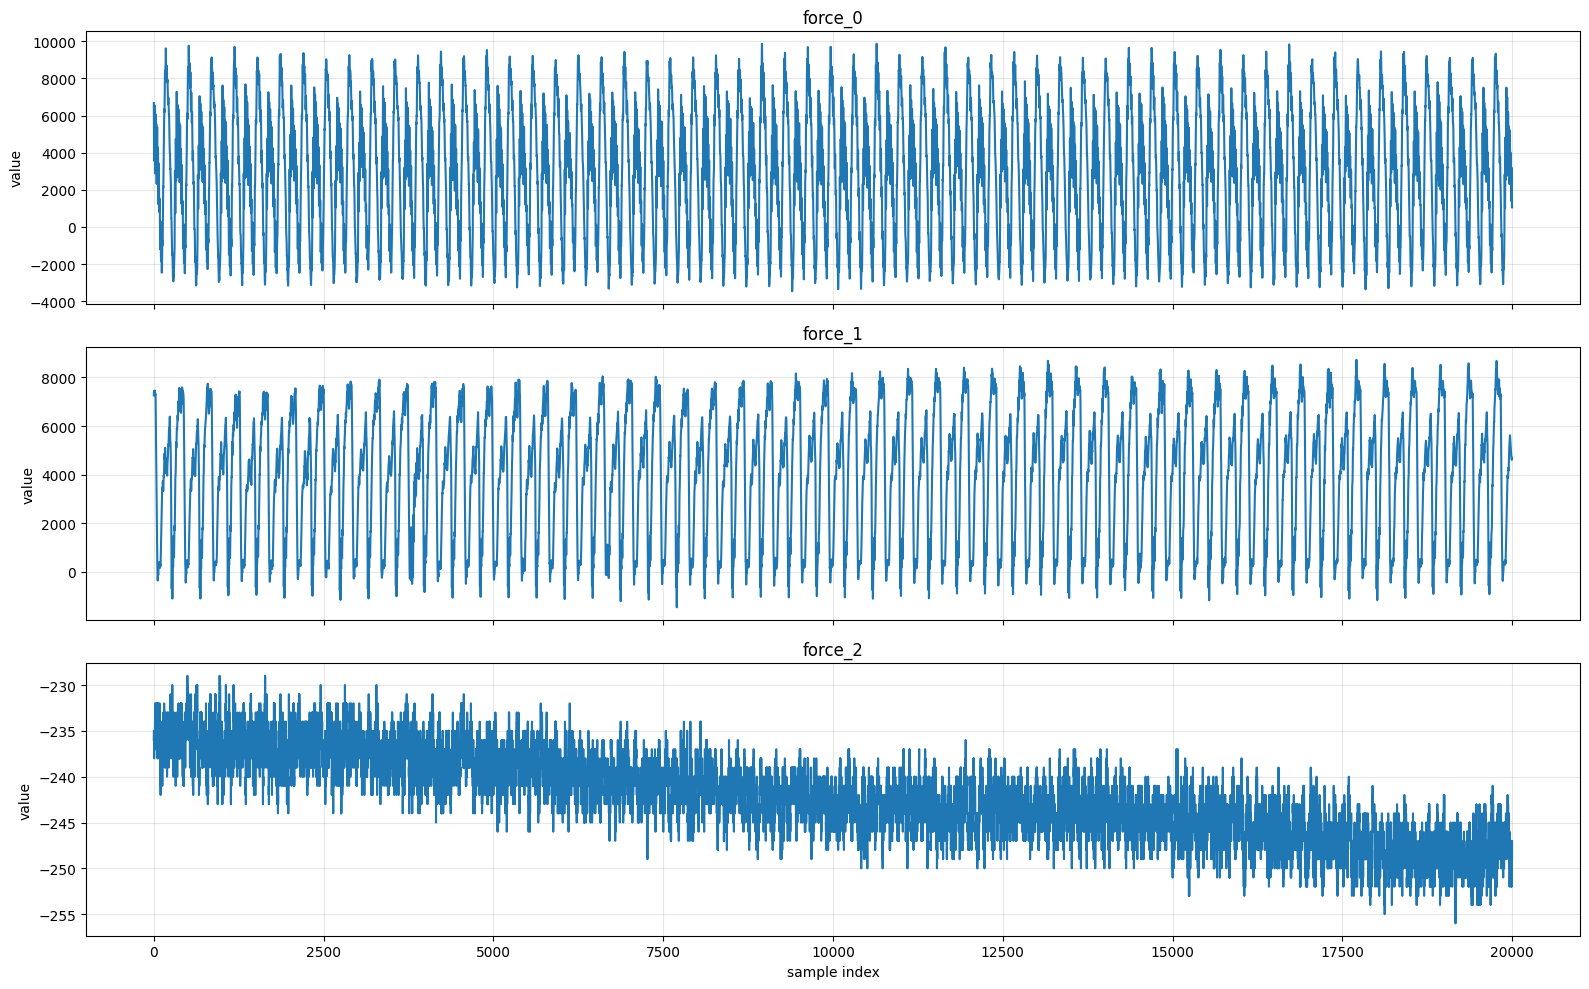

In [189]:
import matplotlib.pyplot as plt

force_names = ["force_0", "force_1", "force_2"]
force_dfs = {name: pd.read_parquet(output_dir / f"{name}.parquet") for name in force_names}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, name in zip(axes, force_names):
    df = force_dfs[name]
    sample_cols = [c for c in df.columns if c.startswith("s") and c[1:].isdigit()]
    ax.plot(df.loc[606, sample_cols].to_numpy(dtype=float))
    ax.set_title(name)
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("sample index")
plt.tight_layout()
plt.show()

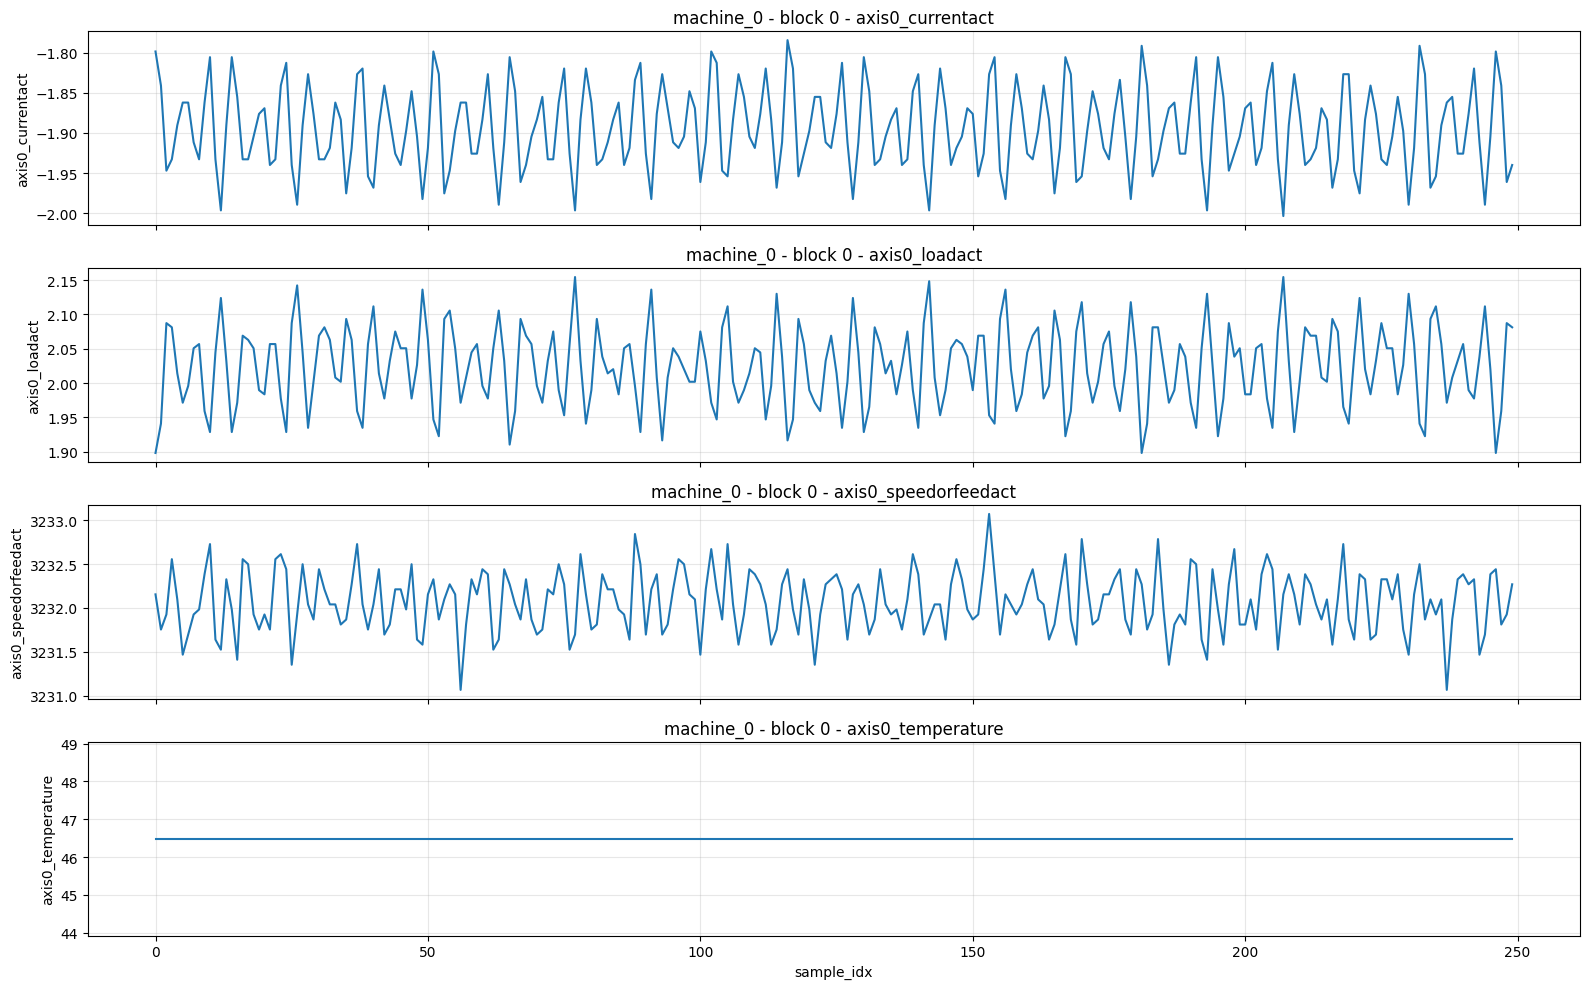

In [ ]:
machine_df = pd.read_parquet(output_dir / "machine_0.parquet")

# Plot a few key machine channels for one block to keep the chart readable
block_to_plot = machine_df["block_idx"].min()
df_plot = machine_df[machine_df["block_idx"] == block_to_plot].sort_values("sample_idx")

plot_cols = [
    "axis0_currentact",
    "axis0_loadact",
    "axis0_speedorfeedact",
    "axis0_temperature",
]
plot_cols = [c for c in plot_cols if c in df_plot.columns]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(16, 10), sharex=True)

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    ax.plot(df_plot["sample_idx"], df_plot[col].to_numpy())
    ax.set_title(f"machine_0 - block {block_to_plot} - {col}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("sample_idx")
plt.tight_layout()
plt.show()

## 11 - Downsample force signals and plot

Concatenates every block for each force channel into one continuous array and
decimates from 20 000 Hz to 1 000 Hz with `scipy.signal.decimate` (zero-phase
Chebyshev I anti-aliasing). Saves one `force_*_ds1000.parquet` per channel,
then shows each channel in its own subplot and all three overlaid on a single
axes.

created force_0_ds20000.parquet  (6,580,000 → 6,580,000 samples)
created force_1_ds20000.parquet  (6,600,000 → 6,600,000 samples)
created force_2_ds20000.parquet  (6,760,000 → 6,760,000 samples)


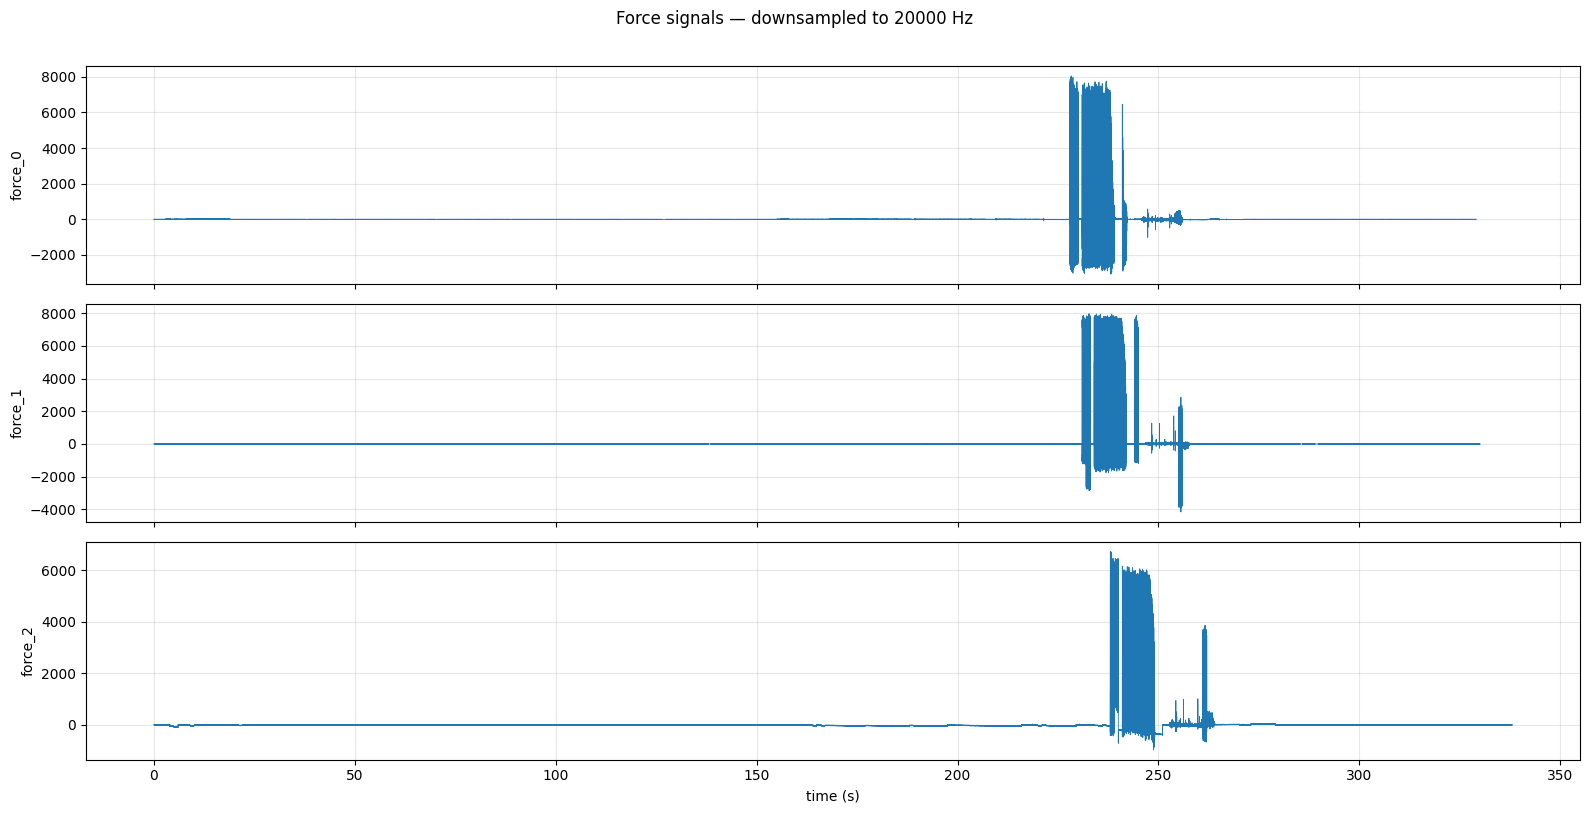

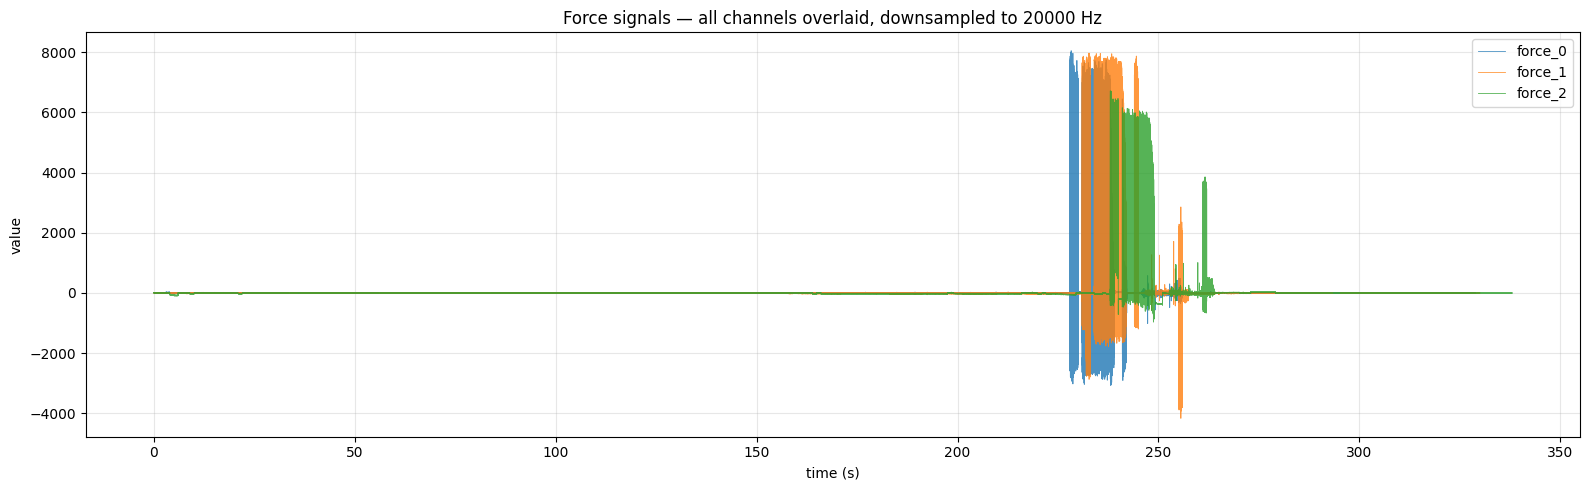

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import decimate

OUTPUT_DIR  = Path("../data/converted/20260629")
ORIGINAL_FS = 20_000
TARGET_FS   = 1_000
DS_RATIO    = ORIGINAL_FS // TARGET_FS
FORCE_NAMES = ["force_0", "force_1", "force_2"]

# --- downsample & save (skipped if files already exist) ---
for name in FORCE_NAMES:
    ds_path = OUTPUT_DIR / f"{name}_ds{TARGET_FS}.parquet"
    if not ds_path.exists():
        df = pd.read_parquet(OUTPUT_DIR / f"{name}.parquet")
        sample_cols = [c for c in df.columns if c.startswith("s") and c[1:].isdigit()]
        raw = df[sample_cols].to_numpy(dtype=float).ravel()
        ds  = decimate(raw, DS_RATIO, zero_phase=True)
        pd.DataFrame({"value": ds}).to_parquet(ds_path, index=False)
        print(f"created {ds_path.name}  ({len(raw):,} → {len(ds):,} samples)")
    else:
        print(f"found   {ds_path.name}")

# --- subplots: one panel per channel ---
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
for ax, name in zip(axes, FORCE_NAMES):
    values = pd.read_parquet(OUTPUT_DIR / f"{name}_ds{TARGET_FS}.parquet")["value"].to_numpy()
    ax.plot([t / TARGET_FS for t in range(len(values))], values, lw=0.6)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Force signals — downsampled to {TARGET_FS} Hz", y=1.01)
plt.tight_layout()
plt.show()

# --- overlay: all three on one axes ---
fig, ax = plt.subplots(figsize=(16, 5))
for name in FORCE_NAMES:
    values = pd.read_parquet(OUTPUT_DIR / f"{name}_ds{TARGET_FS}.parquet")["value"].to_numpy()
    ax.plot([t / TARGET_FS for t in range(len(values))], values, lw=0.6, alpha=0.8, label=name)
ax.set_xlabel("time (s)")
ax.set_ylabel("value")
ax.set_title(f"Force signals — all channels overlaid, downsampled to {TARGET_FS} Hz")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()